In [1]:
from dotenv import load_dotenv
from IPython.display import Image,display
from pydantic import BaseModel,Field
from langchain.agents import create_agent
from langchain.agents.middleware import wrap_tool_call
from langchain_core.tools import tool
from langgraph.checkpoint.memory import MemorySaver
from langchain_mcp_adapters.client import MultiServerMCPClient

load_dotenv(override=True)

True

In [2]:
agent = create_agent(
    model = "gpt-4o-mini",
    system_prompt = "you are a helpful assistant who answers concisely"
)
result = agent.invoke({"messages":[{"role":"user","content":"what is model context protocol , explain in 2 sentences"}]})
print(result["messages"][-1].content)

Model Context Protocol refers to a framework used in machine learning and artificial intelligence to define how a model interacts with its environment, including data inputs and outputs. It establishes a standardized method for managing and interpreting the context in which a model operates, facilitating better integration and communication among different models and systems.


In [3]:
result = await agent.ainvoke({"messages":[{"role":"user","content":"what is async and why suit for agents, explain in 2 sentences"}]})
print(result["messages"][-1].content)

Async, short for asynchronous programming, allows tasks to run concurrently without blocking the main thread, enabling efficient handling of multiple operations, such as I/O tasks. This makes it particularly suitable for agents, as they can process multiple requests or events simultaneously, improving responsiveness and resource utilization.


In [6]:
#tools
@tool
def get_weather(city : str) -> str:
    """Return today's weather for a city."""
    pretend = {"London": "rainy, 14 degrees", "Rome": "sunny, 27 degrees"}
    return pretend.get(city, "clear, 20 degrees")
@tool
def get_population(city: str) -> str:
    """Return the population of a city."""
    pretend = {"London": "8.9 million", "Rome": "2.8 million"}
    return pretend.get(city, "unknown")

agent = create_agent(
    model = "gpt-4o-mini",
    tools =[get_weather,get_population],
    system_prompt = "You are a travel assistant. Use your tools to answer questions about cities."
)
result = agent.invoke({"messages": [{"role": "user", "content": "What is the weather and population of Rome?"}]})
print(result["messages"][-1].content)    

The current weather in Rome is sunny with a temperature of 27 degrees Celsius. The population of Rome is approximately 2.8 million.


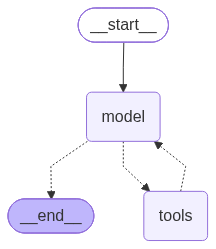

In [7]:
display(Image(agent.get_graph().draw_mermaid_png()))

In [8]:
memory_agent = create_agent(
    model = "gpt-4o-mini",
    tools =[get_weather,get_population],
    checkpointer = MemorySaver()
)
config = {"configurable": {"thread_id":"trip_planning"}}
result = memory_agent.invoke({"messages": [{"role": "user", "content": "What is the weather of rome ?"}]},config=config)
print(result["messages"][-1].content)    

The weather in Rome is sunny with a temperature of 27 degrees Celsius.


#### When you want a typed object back rather than prose, pass a Pydantic model as response_format. The agent still does its work and uses its tools, then fills in your object. You read it from the structured_response key.

In [12]:
#structured_format
class CityReport(BaseModel):
    city : str = Field(description = "the city name")
    weather : str = Field(description="A short weather description")
    population : str = Field(description="The population")
struct_agent = create_agent(
    model = "gpt-4o-mini",
    tools =[get_weather,get_population],
    response_format = CityReport,
)
result = struct_agent.invoke({"messages": [{"role": "user", "content": "Give me a report on London."}]})
print(result["messages"][-1].content)
print(result["structured_response"])

{"city":"London","weather":"rainy, 14 degrees","population":"8.9 million"}
city='London' weather='rainy, 14 degrees' population='8.9 million'


#### Middleware is a powerful feature to shape an agent's behavior. It lets you run your own code at fixed points in the loop: before the model is called, after it answers, or around each tool call.

Here is a small piece of custom middleware that prints every tool call as it happens, so you can watch the agent at work. The @wrap_tool_call decorator wraps each tool call: we log it, then call handler to let it proceed.

In [15]:
@wrap_tool_call
def log_tool_calls(request,handler):
    call = request.tool_call
    print(f"middleware calling {call['name']} and {call['args']}")
    return handler(request)
memory_agent = create_agent(
    model = "gpt-4o-mini",
    tools =[get_weather,get_population],
    checkpointer = MemorySaver(),
    system_prompt="You are a travel assistant. Use your tools.",
    middleware=[log_tool_calls],
    response_format = CityReport,
)
config = {"configurable": {"thread_id":"trip_planning"}}
result = memory_agent.invoke({"messages": [{"role": "user", "content": "Weather and population of London and Rome??"}]},config=config)
print(result["messages"][-1].content)   
    

middleware calling get_weather and {'city': 'London'}
middleware calling get_population and {'city': 'London'}
middleware calling get_weather and {'city': 'Rome'}
middleware calling get_population and {'city': 'Rome'}
{"city":"London","weather":"rainy, 14 degrees","population":"8.9 million"}
